In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
import pandas as pd

df = pd.read_csv(r"D:\ML\breast+cancer+wisconsin+diagnostic\wdbc.data", header=None)

print(df.head())
print(df.shape)

         0  1      2      3       4       5        6        7       8   \
0    842302  M  17.99  10.38  122.80  1001.0  0.11840  0.27760  0.3001   
1    842517  M  20.57  17.77  132.90  1326.0  0.08474  0.07864  0.0869   
2  84300903  M  19.69  21.25  130.00  1203.0  0.10960  0.15990  0.1974   
3  84348301  M  11.42  20.38   77.58   386.1  0.14250  0.28390  0.2414   
4  84358402  M  20.29  14.34  135.10  1297.0  0.10030  0.13280  0.1980   

        9   ...     22     23      24      25      26      27      28      29  \
0  0.14710  ...  25.38  17.33  184.60  2019.0  0.1622  0.6656  0.7119  0.2654   
1  0.07017  ...  24.99  23.41  158.80  1956.0  0.1238  0.1866  0.2416  0.1860   
2  0.12790  ...  23.57  25.53  152.50  1709.0  0.1444  0.4245  0.4504  0.2430   
3  0.10520  ...  14.91  26.50   98.87   567.7  0.2098  0.8663  0.6869  0.2575   
4  0.10430  ...  22.54  16.67  152.20  1575.0  0.1374  0.2050  0.4000  0.1625   

       30       31  
0  0.4601  0.11890  
1  0.2750  0.08902  
2  0.

In [20]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave points_mean", "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave points_se", "symmetry_se",
    "fractal_dimension_se",

    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df.columns = columns

print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [21]:
df = df.drop("id", axis=1)

In [22]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 0,
    "B": 1
})

In [23]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [24]:
print(df.head())
print(df.shape)

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          0        17.99         10.38          122.80     1001.0   
1          0        20.57         17.77          132.90     1326.0   
2          0        19.69         21.25          130.00     1203.0   
3          0        11.42         20.38           77.58      386.1   
4          0        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

In [25]:
print(df["diagnosis"].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: int64


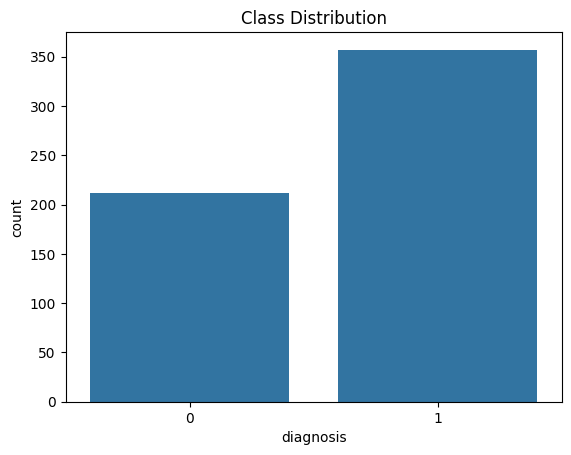

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution")
plt.show()

In [27]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


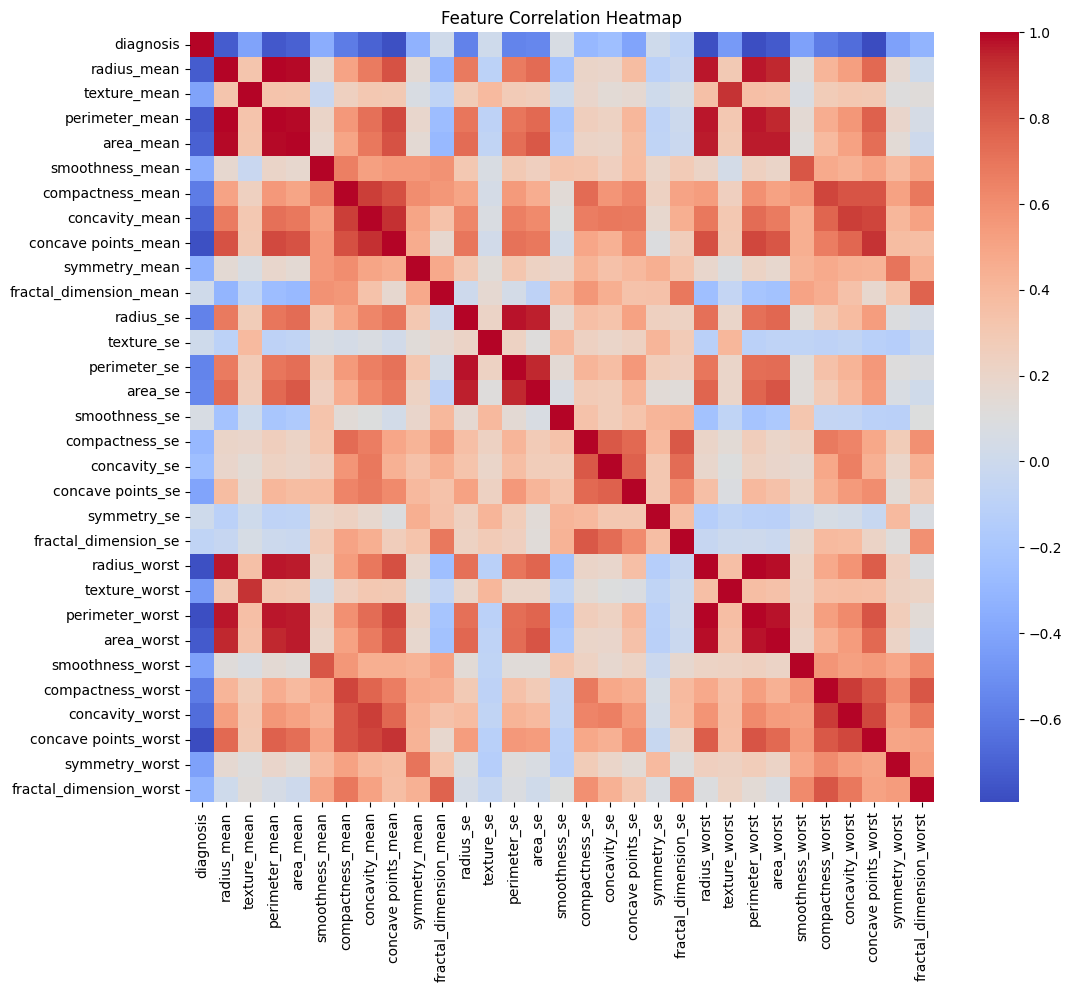

In [28]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [29]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [30]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (455, 30)
Testing set: (114, 30)


In [33]:
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training labels: (455,)
Testing labels: (114,)


In [34]:
print("Train class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Train class distribution:
diagnosis
1    285
0    170
Name: count, dtype: int64

Test class distribution:
diagnosis
1    72
0    42
Name: count, dtype: int64


In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [36]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9122807017543859


In [37]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



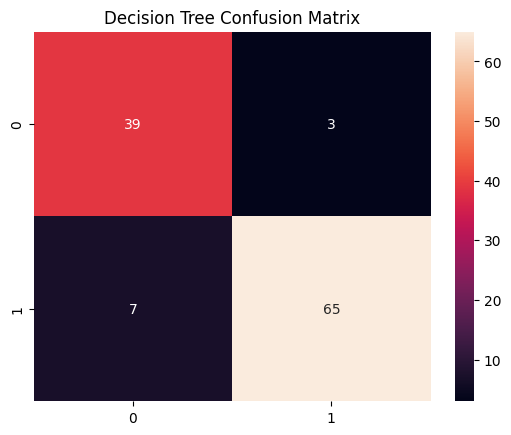

In [38]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [40]:
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

In [41]:
from sklearn.model_selection import GridSearchCV
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [42]:
dt_grid.fit(X_train, y_train)
print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}


In [43]:
print("Best CV Accuracy:", dt_grid.best_score_)

Best CV Accuracy: 0.9384615384615385


In [44]:
best_dt = dt_grid.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

print("Improved Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_best_dt))

Improved Decision Tree Accuracy: 0.9210526315789473


In [45]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.956140350877193


In [46]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



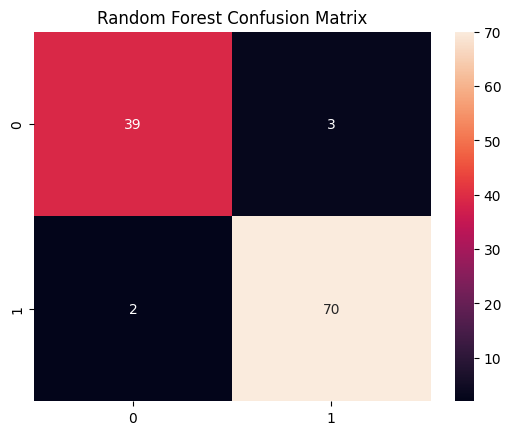

In [47]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [48]:
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [2, 5]
}

In [49]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [50]:
print("Best RF Parameters:", rf_grid.best_params_)

Best RF Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


In [51]:
best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Improved Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))

Improved Random Forest Accuracy: 0.956140350877193


In [52]:
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_best_dt))

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_best_rf))

Decision Tree Accuracy: 0.9210526315789473
Random Forest Accuracy: 0.956140350877193


In [53]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

# Define hyperparameter combinations to test
param_grid = [
    {"n_estimators": 50, "max_depth": 5, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 10, "max_features": "sqrt"},
    {"n_estimators": 200, "max_depth": None, "max_features": "log2"}
]

results = []

for params in param_grid:

    rf = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        max_features=params["max_features"],
        bootstrap=True,
        random_state=42
    )

    scores = cross_validate(
        rf,
        X_train,
        y_train,
        cv=5,
        scoring=["accuracy", "f1"],
        return_train_score=False
    )

    acc = scores["test_accuracy"].mean() * 100
    f1 = scores["test_f1"].mean()

    results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "max_features": params["max_features"],
        "accuracy": round(acc, 2),
        "f1": round(f1, 3)
    })


# Convert to DataFrame
results_df = pd.DataFrame(results)

print("\nRandom Forest Cross Validation Results:\n")
print(results_df)


Random Forest Cross Validation Results:

   n_estimators  max_depth max_features  accuracy     f1
0            50        5.0         sqrt     95.16  0.962
1           100       10.0         sqrt     95.38  0.963
2           200        NaN         log2     95.60  0.965


In [54]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create 5-fold splitter
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_fold_acc = []
rf_fold_acc = []

# Use your best parameters
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features='log2',
    bootstrap=True,
    random_state=42
)

# Loop through folds
for train_index, val_index in kf.split(X_train, y_train):

    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

    # Decision Tree
    dt_model.fit(X_fold_train, y_fold_train)
    dt_pred = dt_model.predict(X_fold_val)
    dt_fold_acc.append(accuracy_score(y_fold_val, dt_pred) * 100)

    # Random Forest
    rf_model.fit(X_fold_train, y_fold_train)
    rf_pred = rf_model.predict(X_fold_val)
    rf_fold_acc.append(accuracy_score(y_fold_val, rf_pred) * 100)

# Convert to numpy
dt_fold_acc = np.array(dt_fold_acc)
rf_fold_acc = np.array(rf_fold_acc)

print("Decision Tree Fold Accuracies:", dt_fold_acc)
print("Decision Tree Average:", dt_fold_acc.mean())

print("\nRandom Forest Fold Accuracies:", rf_fold_acc)
print("Random Forest Average:", rf_fold_acc.mean())

Decision Tree Fold Accuracies: [94.50549451 92.30769231 91.20879121 92.30769231 89.01098901]
Decision Tree Average: 91.86813186813188

Random Forest Fold Accuracies: [95.6043956  96.7032967  93.40659341 96.7032967  97.8021978 ]
Random Forest Average: 96.04395604395604


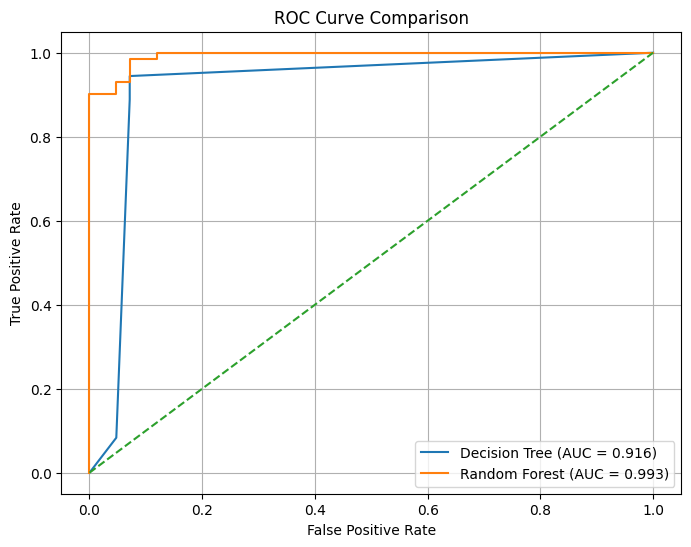

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get probability predictions
dt_probs = best_dt.predict_proba(X_test)[:, 1]
rf_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# Compute AUC
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# Diagonal line (random classifier)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.grid()

# Save image
plt.savefig("roc_curve.png", dpi=300)

plt.show()